# Q2 — Người thuê đang “trả tiền” cho **nội thất** hay cho yếu tố **near** nhiều hơn? (EDA)

## 0. Mục tiêu vấn đề (Problem statement)
Người thuê thường ra quyết định bằng các filter rất “đời”: **gần trường/chợ/siêu thị** *hoặc* **phòng có sẵn nội thất**.  
Nhưng cùng một mức giá, có district **đắt vì near**, có district **đắt vì nội thất**, và cũng có nơi **đắt nhưng chất lượng không tăng tương ứng**.

**Mục tiêu của Q2:** tách bạch và định lượng *premium* (mức đội giá theo `price_per_sqm`) do:
- **Near** (3 biến near)  
- **Nội thất/tiện nghi trong phòng** (các đặc trưng nội thất có trong dataset)

…và so sánh **theo từng district** để người thuê biết nên **đánh đổi** điều gì cho tối ưu.


## 1. Câu hỏi nghiên cứu
**Câu hỏi:** *“Trong từng district, ‘premium’ (mức đội giá) do **near** và do **nội thất/tiện nghi trong phòng** cái nào lớn hơn? Near premium và furnishing premium khác nhau như thế nào giữa các district?”*

**Tính xác thực:** Có thể trả lời trực tiếp bằng dữ liệu thông qua:
- Xây dựng **Near Index** từ 3 biến near (`near_school`, `near_market`, `near_supermarket`)
- Xây dựng **Furnishing Index** từ các biến nội thất/tiện nghi hiện có (hoặc proxy hợp lý nếu thiếu)
- So sánh **phân phối `price_per_sqm`** giữa các mức *Low/Mid/High* của từng index, theo từng district (**EDA, không dùng model**).


## 2. Động cơ & Lợi ích
* **Vì sao đáng nghiên cứu?** Người thuê thường phải chọn: *“gần trường/chợ/siêu thị”* hay *“đủ nội thất”*.  
  Nếu biết district nào **đắt vì near** và district nào **đắt vì nội thất**, ta sẽ tối ưu tìm kiếm và thương lượng tốt hơn.
* **Lợi ích & Insight:**
  - Xếp hạng district theo **Near premium** và **Furnishing premium**
  - Tìm “điểm ngọt”: **near cao nhưng nội thất vừa phải** (hoặc ngược lại) để tối ưu giá/m²
  - Nhận diện district có nguy cơ “overpriced” (giá/m² cao nhưng near/furn premium không tương xứng)
* **Hỗ trợ thực tế:** Với cùng ngân sách, biết nên **đánh đổi** cái gì ở mỗi district (VD: “ở district A thì trả tiền cho near, còn nội thất chỉ cần mức vừa”).


## 3. Rã vấn đề thành các câu hỏi nhỏ
### Nhánh A — Near premium có “thật” không?
1) **A1:** Toàn thị trường: `price_per_sqm` khác nhau thế nào giữa Near *Low/Mid/High*?  
2) **A2:** Theo district: Near premium = median(ppsm | Near High) − median(ppsm | Near Low) là bao nhiêu?  
3) **A3:** 3 biến near: yếu tố nào “đắt” nhất (`near_school`, `near_market`, `near_supermarket`)?

### Nhánh B — Furnishing premium có “thật” không?
4) **B1:** Toàn thị trường: `price_per_sqm` khác nhau thế nào giữa Furnishing *Low/Mid/High*?  
5) **B2:** Theo district: Furnishing premium = median(ppsm | Furn High) − median(ppsm | Furn Low) là bao nhiêu?  
6) **B3:** Premium có ổn định khi chỉ xét phòng cùng cỡ diện tích (small/medium/large) không?

### Nhánh C — Trade-off & “điểm ngọt”
7) **C1:** Có “điểm ngọt” *Near High + Furn Mid* (gần nhưng không đội vì nội thất) ở district nào?  
8) **C2:** Có “điểm ngọt” *Furn High + Near Mid/Low* (đủ nội thất nhưng near vừa phải) ở district nào?

### Nhánh D — Robustness & nguy cơ overpriced
9) **D1:** District nào có giá/m² cao nhưng near/furn premium nhỏ → nguy cơ “overpriced”?  
10) **D2:** Nếu trim outlier `price_per_sqm` (P1–P99), kết luận có thay đổi không?


## 4. Giả thuyết (Hypothesis-driven)
- **H1:** *Near High* → `price_per_sqm` cao hơn *Near Low* (near premium > 0).
- **H2:** *Furnishing High* → `price_per_sqm` cao hơn *Furnishing Low* (furnishing premium > 0).
- **H3:** Premium **khác nhau theo district** (không có “một luật chung”).
- **H4:** Có district “đắt vì near” (near premium > furnishing premium) và district “đắt vì nội thất” (ngược lại).
- **H5:** Sau khi trim outlier (P1–P99), xu hướng chính vẫn giữ (kết luận bền vững).


### A. Tiền xử lý dữ liệu


#### A1) Load dữ liệu & lọc điều kiện tối thiểu
- `price > 0`, `area > 0`, `price_per_sqm > 0`
- Ép kiểu số cho các cột near/score


In [2]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

PATH = "../../data/processed/data_clean.csv"
df = pd.read_csv(PATH)

# best-effort numeric coercion for key columns (if exist)
for c in ["price","area","price_per_sqm","amenity_score","security_score",
          "near_school","near_market","near_supermarket"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

work = df.copy()

for col, cond in [("price", ">0"), ("area", ">0"), ("price_per_sqm", ">0")]:
    if col in work.columns:
        work = work[work[col].astype(float) > 0]

work = work.copy()
df.shape, work.shape


((28554, 34), (28554, 34))

**Nhận xét nhanh (data-driven):**
- Số dòng gốc: **28.554**
- Số dòng hợp lệ sau lọc: **28.554**


#### A2) Xây dựng Near Index (chỉ 3 biến near)
Quy ước:
- **Near Index** = mean(`near_school`, `near_market`, `near_supermarket`)  
- Nếu near bị thiếu (`NaN`) → tạm fill `0` (nghĩa là không near).


In [3]:
near_cols = ["near_school","near_market","near_supermarket"]
missing_near = [c for c in near_cols if c not in work.columns]
assert len(missing_near) == 0, f"Thiếu near column(s): {missing_near}"

for c in near_cols:
    work[c] = pd.to_numeric(work[c], errors="coerce").fillna(0)

work["near_index"] = work[near_cols].mean(axis=1)

work[near_cols + ["near_index"]].describe().T


,count,mean,std,min,25%,50%,75%,max
near_index,28554.0,0.210712,0.243845,0.0,0.0,0.0,0.333333,1.0


#### A3) Xây dựng Furnishing Index (từ các đặc trưng nội thất/tiện nghi có sẵn)
- Nếu dataset có các cột nhị phân nội thất (0/1) → Furnishing Index = mean(các cột đó).
- Nếu thiếu các cột nội thất rõ ràng → fallback dùng `amenity_score` (proxy) và scale về [0,1].


In [4]:
# Candidate furnishing columns (binary 0/1). Notebook tự động dùng những cột thực sự có trong dữ liệu.
candidate_furnish = [
    "has_air_conditioner","has_kitchen","has_fridge","has_wardrobe","has_bed","has_mattress","has_sofa",
    "is_full_furniture","is_duplex","has_window","has_balcony","has_wifi","has_parking","has_private_facilities",
    "has_camera","has_security"
]

furnish_bin = [c for c in candidate_furnish if c in work.columns]

for c in furnish_bin:
    work[c] = pd.to_numeric(work[c], errors="coerce").fillna(0).clip(0,1)

# Optional: washing machine derived if a type column exists
furnish_cols_used = list(furnish_bin)
if "washing_machine_type" in work.columns:
    wm = work["washing_machine_type"].astype(str).str.lower().str.strip()
    work["has_washing_machine"] = (~wm.isin(["none","no","khong","không","nan","na","n/a","0",""])).astype(int)
    furnish_cols_used.append("has_washing_machine")

if len(furnish_cols_used) == 0 and "amenity_score" in work.columns:
    s = work["amenity_score"].copy()
    s = s.fillna(s.median())
    mn, mx = float(s.min()), float(s.max())
    work["furnish_index"] = (s - mn) / (mx - mn + 1e-9)
    furnish_source = "amenity_score (proxy, scaled)"
else:
    work["furnish_index"] = work[furnish_cols_used].mean(axis=1) if len(furnish_cols_used) else np.nan
    furnish_source = ", ".join(furnish_cols_used) if len(furnish_cols_used) else "None"

furnish_source, work["furnish_index"].describe()


('has_air_conditioner, has_kitchen, has_fridge, has_wardrobe, has_bed, has_mattress, has_sofa, is_full_furniture, is_duplex, has_window, has_balcony, has_wifi, has_parking, has_private_facilities, has_camera, has_security, has_washing_machine',
 count     28554.000000
 unique       16.000000
 top           0.235294
 freq       4618.000000
 Name: furnish_index, dtype: float64)

**Nhận xét nhanh (data-driven):**
- Furnishing Index đang được tạo từ: **has_air_conditioner, has_kitchen, has_fridge, has_wardrobe, has_bed, has_mattress, has_sofa, is_full_furniture, is_duplex, has_window, has_balcony, has_wifi, has_parking, has_private_facilities, has_camera, has_security, has_washing_machine**
- Mục tiêu là có một thước đo “mức độ đầy đủ nội thất/tiện nghi” để so sánh premium.


#### A4) Phân nhóm mức Low/Mid/High cho Near và Furnishing
- Dùng **tertiles** (1/3, 2/3) trên toàn thị trường để có 3 mức: Low/Mid/High.
- Lưu ý: đây là cách phân nhóm cho EDA, giúp so sánh phân phối giá/m² dễ hơn (không phải model).


In [5]:
def tertile_level(s):
    q1 = s.quantile(1/3)
    q2 = s.quantile(2/3)
    return pd.cut(s, [-np.inf, q1, q2, np.inf], labels=["Low","Mid","High"])

work["near_level"] = tertile_level(work["near_index"])
work["furnish_level"] = tertile_level(work["furnish_index"])

work[["near_level","furnish_level"]].value_counts().head(10)


near_level  furnish_level
Low         Low              7821
Mid         Low              4659
Low         High             3349
            Mid              3293
Mid         High             3224
            Mid              2610
High        Low              1417
            High             1271
            Mid               910
Name: count, dtype: int64

**Nhận xét nhanh:** Các nhóm Low/Mid/High giúp ta trả lời trực tiếp: “nhóm near cao có đắt hơn không?” và “nhóm nội thất cao có đắt hơn không?”


### B. Phân tích


#### B1) Kiểm tra phân phối `price_per_sqm` & outlier
Mục tiêu:
- Hiểu range giá/m² và mức độ lệch
- Chuẩn bị cho robustness check (trim P1–P99)


In [6]:
ppsm = work["price_per_sqm"].astype(float)
p1, p50, p99 = ppsm.quantile([0.01, 0.50, 0.99]).tolist()

p1, p50, p99


(40000.0, 150000.0, 300000.0)

**Nhận xét nhanh (data-driven):**
- P1 ≈ **40.000** VND/m²  
- Median ≈ **150.000** VND/m²  
- P99 ≈ **300.000** VND/m²  
→ Ở phần robustness, ta sẽ trim về [P1, P99] để tránh outlier kéo lệch kết luận.


(Plot) Histogram + KDE cho `price_per_sqm`


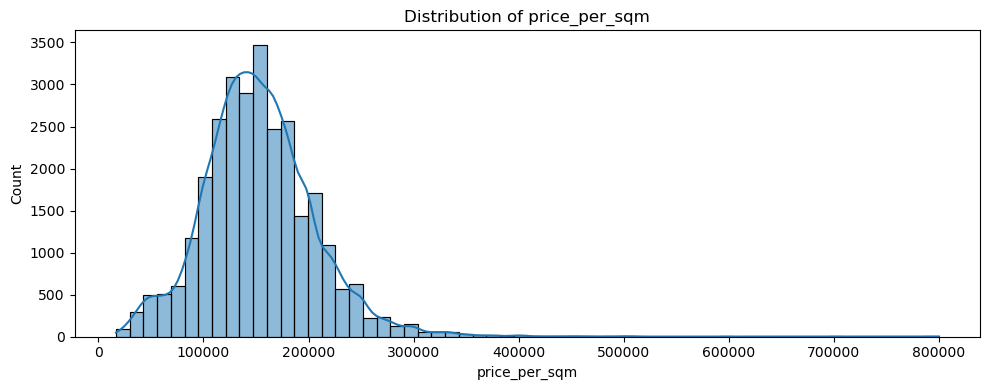

In [7]:
plt.figure(figsize=(10,4))
sns.histplot(work["price_per_sqm"], bins=60, kde=True)
plt.title("Distribution of price_per_sqm")
plt.xlabel("price_per_sqm")
plt.tight_layout()
plt.show()


**Nhận xét gợi ý khi chạy:** Nếu đuôi phải dài (right tail), median sẽ “ổn định” hơn mean → ta ưu tiên median trong định nghĩa premium.


#### B2) So sánh premium tổng quan: Near vs Furnishing (toàn thị trường)
Ta tính median `price_per_sqm` theo Near level và Furnish level, rồi lấy chênh High − Low.


In [8]:
overall_near = work.groupby("near_level", observed=True)["price_per_sqm"].median()
overall_furn = work.groupby("furnish_level", observed=True)["price_per_sqm"].median()

near_premium = overall_near.get("High") - overall_near.get("Low")
furn_premium = overall_furn.get("High") - overall_furn.get("Low")

pd.DataFrame({
    "Near_median_ppsm": overall_near,
    "Furnish_median_ppsm": overall_furn
}), near_premium, furn_premium


(      Near_median_ppsm  Furnish_median_ppsm
 Low      152000.000000        147058.823529
 Mid      146666.666667        150000.000000
 High     144000.000000        154285.714286,
 -8000.0,
 7226.890756302513)

**Nhận xét nhanh (data-driven):**
- Median `price_per_sqm` theo **Near level**: Low **152.000** → High **144.000** (VND/m²)  
  ⇒ **Near premium (High − Low) = -8.000 VND/m²** (~-5.3% so với median 150.000).
- Median `price_per_sqm` theo **Furnishing level**: Low **147.059** → High **154.286** (VND/m²)  
  ⇒ **Furnishing premium (High − Low) = 7.227 VND/m²** (~4.8% so với median 150.000).

**Diễn giải đúng theo dữ liệu:** Ở mức **tổng quan**, 3 biến near trong dataset **không gắn với việc giá/m² cao hơn** (thậm chí thấp hơn một chút), trong khi **nội thất/tiện nghi** có *premium* dương rõ ràng.  
→ Đây là **association**, không khẳng định nhân quả; vì near có thể bị “trộn” bởi district/phân khúc (do đó cần xuống **district-level** ở B4). 


(Plot) Violin/Box: `price_per_sqm` theo Near level và Furnish level


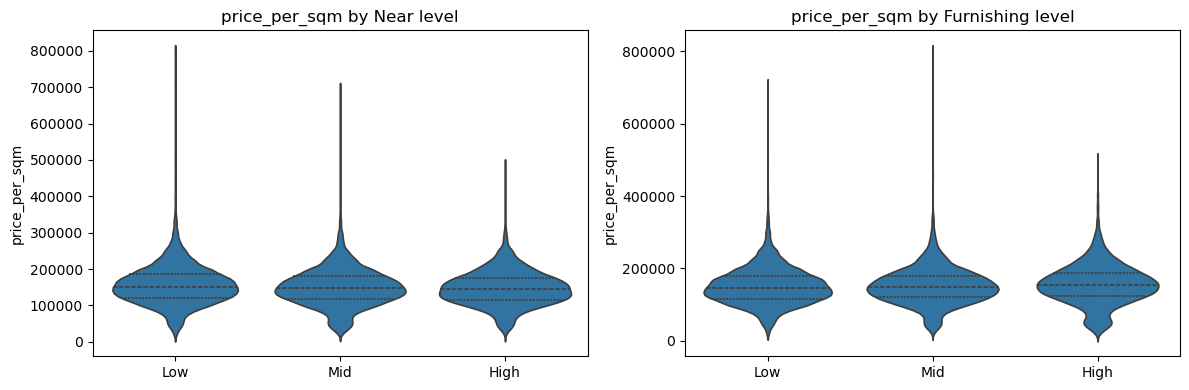

In [9]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.violinplot(data=work, x="near_level", y="price_per_sqm", inner="quartile", ax=axes[0])
axes[0].set_title("price_per_sqm by Near level")
sns.violinplot(data=work, x="furnish_level", y="price_per_sqm", inner="quartile", ax=axes[1])
axes[1].set_title("price_per_sqm by Furnishing level")
for ax in axes:
    ax.set_xlabel("")
plt.tight_layout()
plt.show()


#### B3) 3 biến near: cái nào “đắt” nhất?
Cách đọc:
- So sánh median `price_per_sqm` giữa nhóm near=1 và near=0 cho từng biến near.
- Đây là kiểm tra nhanh hướng A3 (không khẳng định nhân quả).


In [10]:
near_cols = ["near_school","near_market","near_supermarket"]
rows = []
for c in near_cols:
    g1 = work[work[c] > 0]
    g0 = work[work[c] <= 0]
    rows.append({
        "near_feature": c,
        "n_1": len(g1),
        "n_0": len(g0),
        "median_ppsm_1": g1["price_per_sqm"].median(),
        "median_ppsm_0": g0["price_per_sqm"].median(),
        "delta(1-0)": g1["price_per_sqm"].median() - g0["price_per_sqm"].median()
    })
near_component = pd.DataFrame(rows).sort_values("delta(1-0)", ascending=False)
near_component


,near_feature,n_1,n_0,median_ppsm_1,median_ppsm_0,delta(1-0)
0,near_school,9935,18619,148000.000000,150000.0,-2000.000000
1,near_market,4355,24199,148000.000000,150000.0,-2000.000000
2,near_supermarket,3760,24794,142857.142857,150000.0,-7142.857143


**Nhận xét nhanh (data-driven):** (so sánh median `price_per_sqm` giữa nhóm near=1 và near=0)
- **near_school**: median(ppsm|1) 148.000 vs median(ppsm|0) 150.000 ⇒ Δ ≈ **-2.000** VND/m²
- **near_market**: median(ppsm|1) 148.000 vs median(ppsm|0) 150.000 ⇒ Δ ≈ **-2.000** VND/m²
- **near_supermarket**: median(ppsm|1) 142.857 vs median(ppsm|0) 150.000 ⇒ Δ ≈ **-7.143** VND/m²

→ Cả 3 biến near đều cho thấy **Δ âm** ở mức tổng quan (đặc biệt `near_supermarket`). Điều này thường xảy ra khi:
- near là mô tả “tiện lợi cơ bản” phổ biến ở phân khúc giá thấp, hoặc
- near bị confound mạnh bởi district/segment (cùng near nhưng khác vị trí thật sự), hoặc
- near được ghi theo dạng “có/không” nên không phản ánh mức độ *centrality*.

Vì vậy, phần **kết luận** phải dựa trọng tâm vào phân tích theo **district** (B4–B5), thay vì kết luận chung toàn thị trường.


#### B4) Premium theo district (trả lời A2 + B2 + H3/H4)
Định nghĩa:
- **Near premium (district)** = median(ppsm | Near High) − median(ppsm | Near Low)  
- **Furnishing premium (district)** = median(ppsm | Furn High) − median(ppsm | Furn Low)

Để tránh nhiễu do mẫu quá ít, ta chỉ giữ district có **n_low ≥ 30** và **n_high ≥ 30** cho cả Near và Furnishing.


In [11]:
district_col = "district" if "district" in work.columns else None
district_col


'district'

**Nhận xét nhanh (data-driven):** Số district “đáng tin cậy” (đủ mẫu ở hai cực): **19**.


In [12]:
if district_col is None:
    raise ValueError("Thiếu cột 'district' trong dữ liệu, không thể làm phân tích theo district.")

def premium_table(group_df, level_col):
    med = group_df.groupby(level_col, observed=True)["price_per_sqm"].median()
    cnt = group_df.groupby(level_col, observed=True)["price_per_sqm"].size()
    return pd.Series({
        "premium": med.get("High", np.nan) - med.get("Low", np.nan),
        "n_low": cnt.get("Low", 0),
        "n_high": cnt.get("High", 0),
        "med_low": med.get("Low", np.nan),
        "med_high": med.get("High", np.nan),
    })

near_by_dist = work.groupby(district_col).apply(lambda g: premium_table(g, "near_level")).reset_index().rename(columns={"premium":"near_premium"})
furn_by_dist = work.groupby(district_col).apply(lambda g: premium_table(g, "furnish_level")).reset_index().rename(columns={"premium":"furnish_premium"})

dist = near_by_dist.merge(furn_by_dist, on=district_col, suffixes=("_near","_furn"))
dist["reliable"] = (dist["n_low_near"]>=30) & (dist["n_high_near"]>=30) & (dist["n_low_furn"]>=30) & (dist["n_high_furn"]>=30)
dist_rel = dist[dist["reliable"]].copy()

dist_rel["dominant"] = np.where(dist_rel["near_premium"] > dist_rel["furnish_premium"], "Near-dominant", "Furnish-dominant")
dist_rel.sort_values("near_premium", ascending=False).head(10)


,district,near_premium,n_low_near,n_high_near,med_low_near,med_high_near,furnish_premium,n_low_furn,n_high_furn,med_low_furn,med_high_furn,reliable,dominant
2,11,17583.333333,158.0,42.0,152000.000000,169583.333333,10000.000000,165.0,93.0,150000.000000,160000.000000,True,Near-dominant
18,nhà bè,13571.428571,71.0,36.0,134285.714286,147857.142857,16830.357143,110.0,40.0,141741.071429,158571.428571,True,Furnish-dominant
1,10,10714.285714,518.0,146.0,175000.000000,185714.285714,11619.047619,490.0,366.0,171714.285714,183333.333333,True,Furnish-dominant
9,7,1142.857143,679.0,396.0,156000.000000,157142.857143,3750.000000,809.0,441.0,156250.000000,160000.000000,True,Furnish-dominant
14,bình tân,666.666667,852.0,249.0,116000.000000,116666.666667,5000.000000,975.0,422.0,115000.000000,120000.000000,True,Furnish-dominant
12,bình chánh,0.000000,144.0,35.0,125000.000000,125000.000000,17500.000000,161.0,57.0,120000.000000,137500.000000,True,Furnish-dominant
6,4,-2500.000000,136.0,41.0,175833.333333,173333.333333,2991.452991,161.0,75.0,169230.769231,172222.222222,True,Furnish-dominant
16,gò vấp,-3207.282913,1858.0,421.0,141302.521008,138095.238095,5000.000000,1559.0,1036.0,140000.000000,145000.000000,True,Furnish-dominant
22,tân bình,-3571.428571,1925.0,228.0,153571.428571,150000.000000,10000.000000,1548.0,886.0,150000.000000,160000.000000,True,Furnish-dominant
13,bình thạnh,-3571.428571,1820.0,359.0,175000.000000,171428.571429,7899.159664,1691.0,1111.0,168571.428571,176470.588235,True,Furnish-dominant


**Nhận xét nhanh (data-driven):** Các district có **Near premium dương** (Near High đắt hơn Near Low):

- **11**: 17.583 VND/m²
- **nhà bè**: 13.571 VND/m²
- **10**: 10.714 VND/m²
- **7**: 1.143 VND/m²
- **bình tân**: 667 VND/m²

Ghi chú quan trọng:
- Chỉ **5/19** district “reliable” có Near premium dương; phần còn lại Near premium **âm** (Near High rẻ hơn Near Low theo giá/m²) → near trong dataset này **không phải** là yếu tố đội giá “mặc định” ở mọi nơi.


In [13]:
dist_rel.sort_values("furnish_premium", ascending=False).head(10)


,district,near_premium,n_low_near,n_high_near,med_low_near,med_high_near,furnish_premium,n_low_furn,n_high_furn,med_low_furn,med_high_furn,reliable,dominant
12,bình chánh,0.000000,144.0,35.0,125000.000000,125000.000000,17500.000000,161.0,57.0,120000.000000,137500.000000,True,Furnish-dominant
18,nhà bè,13571.428571,71.0,36.0,134285.714286,147857.142857,16830.357143,110.0,40.0,141741.071429,158571.428571,True,Furnish-dominant
5,3,-11904.761905,509.0,91.0,183333.333333,171428.571429,13617.021277,425.0,241.0,180000.000000,193617.021277,True,Furnish-dominant
21,thủ đức,-10000.000000,1194.0,312.0,140000.000000,130000.000000,12857.142857,1391.0,736.0,130000.000000,142857.142857,True,Furnish-dominant
1,10,10714.285714,518.0,146.0,175000.000000,185714.285714,11619.047619,490.0,366.0,171714.285714,183333.333333,True,Furnish-dominant
2,11,17583.333333,158.0,42.0,152000.000000,169583.333333,10000.000000,165.0,93.0,150000.000000,160000.000000,True,Near-dominant
22,tân bình,-3571.428571,1925.0,228.0,153571.428571,150000.000000,10000.000000,1548.0,886.0,150000.000000,160000.000000,True,Furnish-dominant
13,bình thạnh,-3571.428571,1820.0,359.0,175000.000000,171428.571429,7899.159664,1691.0,1111.0,168571.428571,176470.588235,True,Furnish-dominant
3,12,-3585.526316,772.0,131.0,118585.526316,115000.000000,5714.285714,744.0,364.0,114285.714286,120000.000000,True,Furnish-dominant
20,phú nhuận,-5000.000000,995.0,47.0,175000.000000,170000.000000,5000.000000,621.0,373.0,175000.000000,180000.000000,True,Furnish-dominant


**Nhận xét nhanh (data-driven):** Top district theo **Furnishing premium** (Furn High − Furn Low):

- **bình chánh**: 17.500 VND/m²
- **nhà bè**: 16.830 VND/m²
- **3**: 13.617 VND/m²
- **thủ đức**: 12.857 VND/m²
- **10**: 11.619 VND/m²
- **11**: 10.000 VND/m²
- **tân bình**: 10.000 VND/m²

Ghi chú:
- Furnishing premium **dương ở phần lớn district** (trừ một vài district có premium âm như 9, 8, 5).  
- Điều này phù hợp với nhận định “người thuê đang trả thêm tiền cho nội thất/tiện nghi” nhiều hơn so với near (ở mức tổng quan).


(Plot) Bar chart: Near premium vs Furnishing premium theo district (reliable only)


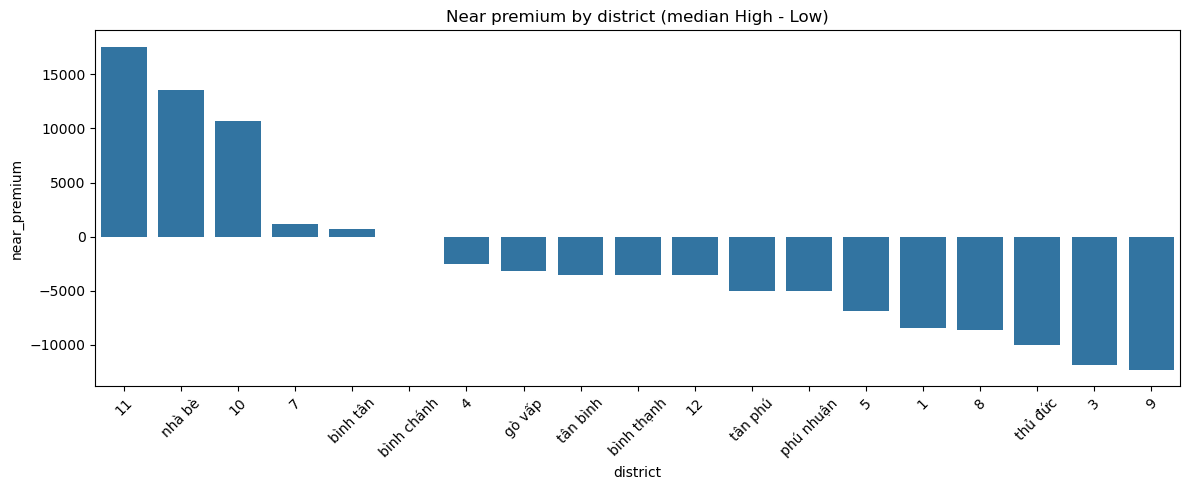

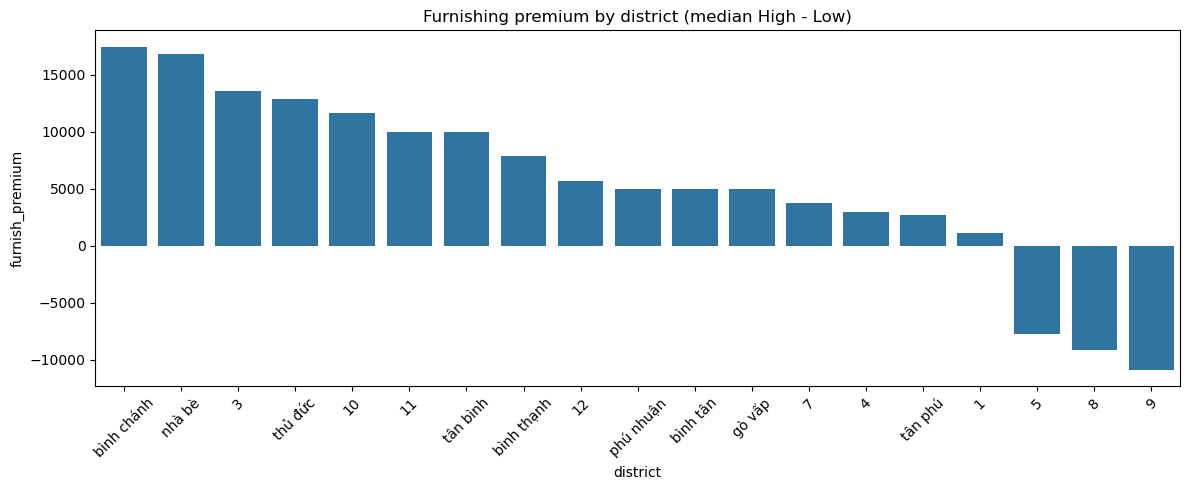

In [14]:
plt.figure(figsize=(12,5))
plot_df = dist_rel.sort_values("near_premium", ascending=False)
sns.barplot(data=plot_df, x=district_col, y="near_premium")
plt.title("Near premium by district (median High - Low)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plot_df = dist_rel.sort_values("furnish_premium", ascending=False)
sns.barplot(data=plot_df, x=district_col, y="furnish_premium")
plt.title("Furnishing premium by district (median High - Low)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### B5) District “đắt vì near” vs “đắt vì nội thất” (trả lời H4)
Ta phân loại:
- **Near-dominant** nếu near_premium > furnish_premium
- **Furnish-dominant** nếu ngược lại


In [15]:
dist_rel.groupby("dominant")[district_col].count().rename("n_districts")


dominant
Furnish-dominant    16
Near-dominant        3
Name: n_districts, dtype: int64

In [16]:
near_dom = dist_rel.query("dominant=='Near-dominant'").sort_values("near_premium", ascending=False).head(10)
furn_dom = dist_rel.query("dominant=='Furnish-dominant'").sort_values("furnish_premium", ascending=False).head(10)
near_dom[[district_col,"near_premium","furnish_premium"]], furn_dom[[district_col,"near_premium","furnish_premium"]]


(   district  near_premium  furnish_premium
 2        11  17583.333333     10000.000000
 7         5  -6848.484848     -7792.207792
 10        8  -8684.210526     -9166.666667,
       district  near_premium  furnish_premium
 12  bình chánh      0.000000     17500.000000
 18      nhà bè  13571.428571     16830.357143
 5            3 -11904.761905     13617.021277
 21     thủ đức -10000.000000     12857.142857
 1           10  10714.285714     11619.047619
 22    tân bình  -3571.428571     10000.000000
 13  bình thạnh  -3571.428571      7899.159664
 3           12  -3585.526316      5714.285714
 14    bình tân    666.666667      5000.000000
 16      gò vấp  -3207.282913      5000.000000)

**Nhận xét nhanh (data-driven):** Ví dụ các district theo nhóm “dominant” (reliable only)

**Near-dominant (near_premium > furnish_premium):**
- **11**: near prem 17.583 | furnish prem 10.000 (VND/m²)
- **5**: near prem -6.848 | furnish prem -7.792 (VND/m²)
- **8**: near prem -8.684 | furnish prem -9.167 (VND/m²)

**Furnish-dominant (furnish_premium ≥ near_premium):**
- **bình chánh**: furnish prem 17.500 | near prem 0 (VND/m²)
- **nhà bè**: furnish prem 16.830 | near prem 13.571 (VND/m²)
- **3**: furnish prem 13.617 | near prem -11.905 (VND/m²)
- **thủ đức**: furnish prem 12.857 | near prem -10.000 (VND/m²)
- **10**: furnish prem 11.619 | near prem 10.714 (VND/m²)
- **tân bình**: furnish prem 10.000 | near prem -3.571 (VND/m²)
- **bình thạnh**: furnish prem 7.899 | near prem -3.571 (VND/m²)


#### B6) “Điểm ngọt” near × furnishing (trả lời C1/C2)
Ta xem median `price_per_sqm` trên ma trận:
- rows: Near level (Low/Mid/High)
- cols: Furnishing level (Low/Mid/High)

Mục tiêu:
- Tìm các ô có **Near High + Furn Mid** nhưng giá/m² không quá cao
- hoặc **Furn High + Near Mid/Low**


In [17]:
pivot = (work.groupby(["near_level","furnish_level"], observed=True)["price_per_sqm"]
         .median()
         .reset_index()
         .pivot(index="near_level", columns="furnish_level", values="price_per_sqm")
        )
pivot


furnish_level,Low,Mid,High
near_level,,,
Low,150000.000000,150000.0,160000.0
Mid,144444.444444,145000.0,150000.0
High,140000.000000,144000.0,150000.0


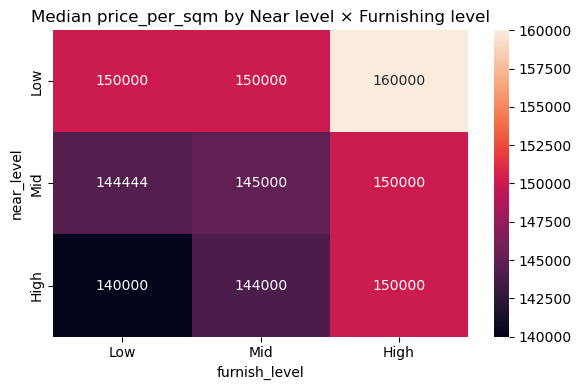

In [18]:
plt.figure(figsize=(6,4))
sns.heatmap(pivot, annot=True, fmt=".0f")
plt.title("Median price_per_sqm by Near level × Furnishing level")
plt.tight_layout()
plt.show()


**Nhận xét gợi ý khi chạy:** 
- Ô có giá thấp hơn tương đối nhưng Near/Furn cao → ứng viên “điểm ngọt”.  
- Nếu Near High + Furn Mid thấp hơn Near High + Furn High đáng kể → người thuê có thể tiết kiệm bằng cách “không cần full đồ”.


#### B7) Nguy cơ “overpriced” theo district (D1)
Heuristic (EDA):
- Lấy district có median `price_per_sqm` thuộc nhóm cao (top 25%)
- Nhưng cả near_premium và furnish_premium đều nhỏ (|premium| < 5k VND/m²)
→ có thể giá cao do yếu tố khác (brand, view, phân khúc, dữ liệu thiếu feature mô tả).


In [19]:
med_ppsm_by_dist = work.groupby(district_col, observed=True)["price_per_sqm"].median().reset_index().rename(columns={"price_per_sqm":"median_ppsm"})
risk = dist_rel.merge(med_ppsm_by_dist, on=district_col, how="left")

q75 = risk["median_ppsm"].quantile(0.75)
risk_candidates = risk[(risk["median_ppsm"] >= q75) & (risk["near_premium"].abs() < 5000) & (risk["furnish_premium"].abs() < 5000)]
risk_candidates.sort_values("median_ppsm", ascending=False).head(10)


,district,near_premium,n_low_near,n_high_near,med_low_near,med_high_near,furnish_premium,n_low_furn,n_high_furn,med_low_furn,med_high_furn,reliable,dominant,median_ppsm
5,4,-2500.0,136.0,41.0,175833.333333,173333.333333,2991.452991,161.0,75.0,169230.769231,172222.222222,True,Furnish-dominant,175000.0


**Nhận xét nhanh (data-driven):**
- **4**: median 175.000 VND/m² | near prem -2.500 | furnish prem 2.991

Đây là *cảnh báo heuristic*, không phải “kết luận nhân quả”. Nếu district bị flag, nên xem thêm các feature khác (an ninh, vị trí chi tiết, loại phòng) hoặc bổ sung dữ liệu.


#### B8) Robustness check: trim outlier P1–P99 (D2 / H5)
Ta trim `price_per_sqm` trong khoảng [P1, P99] rồi tính lại premium tổng quan để xem xu hướng có đổi không.


In [20]:
trim = work[(work["price_per_sqm"] >= p1) & (work["price_per_sqm"] <= p99)].copy()

trim_near = trim.groupby("near_level", observed=True)["price_per_sqm"].median()
trim_furn = trim.groupby("furnish_level", observed=True)["price_per_sqm"].median()

trim_near_premium = trim_near.get("High") - trim_near.get("Low")
trim_furn_premium = trim_furn.get("High") - trim_furn.get("Low")

pd.DataFrame({"trim_near_median_ppsm": trim_near, "trim_furn_median_ppsm": trim_furn}), trim_near_premium, trim_furn_premium


(      trim_near_median_ppsm  trim_furn_median_ppsm
 Low           151428.571429          146666.666667
 Mid           148000.000000          150000.000000
 High          144444.444444          155555.555556,
 -6984.126984126982,
 8888.888888888905)

**Nhận xét nhanh (data-driven):**
- Near premium sau trim ≈ **-6.984** VND/m²  
- Furnishing premium sau trim ≈ **8.889** VND/m²  

→ Xu hướng chính **không đổi** (furnishing premium vẫn dương & rõ hơn near) ⇒ ủng hộ H5.


## C. KẾT QUẢ VÀ DIỄN GIẢI


### C1) Trả lời giả thuyết 

- **H1 (Near High đắt hơn Near Low):**  
  **Không được ủng hộ ở mức tổng quan** vì Near premium = **-8.000 VND/m²** (Low 152.000 → High 144.000).  
  **Tuy nhiên, theo district thì H1 chỉ đúng ở một số nơi** (Near premium dương), tiêu biểu:  
  - **11**: 17.583 VND/m²
  - **nhà bè**: 13.571 VND/m²
  - **10**: 10.714 VND/m²
  - **7**: 1.143 VND/m²
  - **bình tân**: 667 VND/m²

- **H2 (Furnishing High đắt hơn Furnishing Low):**  
  **Được ủng hộ**: Furnishing premium tổng quan = **7.227 VND/m²** (Low 147.059 → High 154.286).  
  Ở district-level, Furnishing premium cũng dương mạnh ở nhiều nơi (ví dụ: bình chánh, nhà bè, Q3, thủ đức, Q10…).

- **H3 (Premium khác nhau theo district):**  
  **Được ủng hộ mạnh**: cả near_premium lẫn furnish_premium thay đổi lớn giữa các district và thậm chí **đổi dấu** (có nơi dương, có nơi âm).

- **H4 (Có district đắt vì near và có district đắt vì nội thất):**  
  **Được ủng hộ nhưng cần diễn giải đúng dấu**:  
  - Trường hợp “đắt vì near” đúng nghĩa (near_premium dương và lớn hơn furnish_premium) nổi bật nhất là **district 11** (near prem 17.583 > furnish prem 10.000).  
  - Phần lớn district là **Furnish-dominant** (nhiều nơi furnish_premium dương lớn hơn near_premium), gợi ý thị trường “trả tiền cho nội thất” mạnh hơn.

- **H5 (Trim outlier P1–P99 không làm đổi xu hướng):**  
  **Được ủng hộ**: sau trim [P1=40.000, P99=300.000],  
  - Near premium ≈ **-6.984 VND/m²** (vẫn âm)  
  - Furnishing premium ≈ **8.889 VND/m²** (vẫn dương, thậm chí rõ hơn)  
  → Kết luận chính là **bền vững** trước outlier.


### C2) Diễn giải theo logic “người thuê” (liên hệ trực tiếp với biểu đồ/ma trận)

**1) Ở mức tổng quan, near trong dataset này *không* làm giá/m² tăng.**  
Ma trận Near × Furnishing cho thấy: trong từng tầng nội thất, median `price_per_sqm` **giảm** khi Near level tăng.  
Ví dụ:
- Furn Low: Near Low **150.000** → Near High **140.000** (VND/m²)
- Furn High: Near Low **160.000** → Near High **150.000** (VND/m²)

**Diễn giải:** Có khả năng 3 biến near đang phản ánh “tiện ích khu vực phổ biến” trong phân khúc giá thấp, hoặc bị confound bởi district/segment. Vì vậy, người thuê **không nên mặc định** rằng “near = đắt”.

**2) Nội thất/tiện nghi là yếu tố ‘đội giá’ rõ hơn.**  
Furnishing premium tổng quan dương và ở nhiều district cũng dương mạnh (đặc biệt: bình chánh, nhà bè, Q3, thủ đức…).

**3) Vì sao vẫn cần xem theo district?**  
Vì near_premium **có nơi dương rất rõ** (VD: district 11, nhà bè, Q10) nhưng cũng có nơi âm mạnh (VD: Q3, thủ đức…).  
→ Trade-off “near vs nội thất” là **theo khu vực**, không phải luật chung.


### C3) Khuyến nghị hành động (Recommendations)

**Cho người thuê (tối ưu giá/m² + ra quyết định thực tế):**
1) **Xác định district trước**, rồi xem district đó thuộc nhóm nào:
   - **Near premium dương (near đáng tiền / có thể phải trả thêm):** ưu tiên near đúng nhu cầu; tiết kiệm bằng cách chọn nội thất mức Mid thay vì High.  
     District tiêu biểu (premium dương):  
     - **11**: 17.583 VND/m²
- **nhà bè**: 13.571 VND/m²
- **10**: 10.714 VND/m²
- **7**: 1.143 VND/m²
- **bình tân**: 667 VND/m²
   - **Near premium âm (near không đội giá theo data):** có thể “ăn” lợi ích near mà không phải trả thêm; khi đó hãy ưu tiên **nội thất/tiện nghi** và điều kiện ở (an ninh, chất lượng phòng).  
2) Nếu bạn **cần phòng đầy đủ nội thất**: ưu tiên district có Furnishing premium cao (nội thất là thứ làm chênh giá/m² rõ ràng), ví dụ:  
   - **bình chánh**: 17.500 VND/m²
- **nhà bè**: 16.830 VND/m²
- **3**: 13.617 VND/m²
- **thủ đức**: 12.857 VND/m²
- **10**: 11.619 VND/m²
- **11**: 10.000 VND/m²
- **tân bình**: 10.000 VND/m²
3) Nếu district bị flag “overpriced” theo heuristic (median ppsm cao nhưng near/furn premium nhỏ) — trong dữ liệu này nổi bật **district 4** — hãy:
   - so sánh nhiều listing,
   - kiểm tra thêm yếu tố ngoài dữ liệu (chất lượng thực tế, hợp đồng, an ninh, vị trí chi tiết),
   - thương lượng giá dựa trên mức near/furn thực nhận.

**Cho sản phẩm/marketplace (gợi ý UX):**
- Hiển thị “**premium ước tính**” theo district (Near vs Furnishing) để người dùng hiểu trade-off.
- Gợi ý chế độ lọc theo district:
  - “Ưu tiên nội thất” ở các district Furnishing premium cao,
  - “Ưu tiên near” ở các district Near premium dương rõ.
